# Movie Success Analysis

This notebook consolidates the project scripts into one reproducible pandas workflow. It loads the TMDB movie CSV, removes unused columns, splits movies into decade groups, creates all-movie and U.S.-only summaries, ranks genres, optionally exports CSV outputs, and builds matplotlib visualizations.

Expected input file: `Dataset/TMDB_movie_dataset_v11.csv`. A root-level `TMDB_movie_dataset_v11.csv` is also supported as a fallback.

In [1]:
from pathlib import Path
import ast
import json
import re

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

DATASET_PATHS = [
    Path("Dataset") / "TMDB_movie_dataset_v11.csv",
    Path("TMDB_movie_dataset_v11.csv"),
]
DATASET_PATH = next((path for path in DATASET_PATHS if path.exists()), DATASET_PATHS[0])
ALL_OUTPUT_DIR = Path("MoreThanJustUS")
US_OUTPUT_DIR = Path("OnlyUSdata")

## Configuration

These values mirror the standalone scripts in the repository.

In [2]:
COLUMNS_TO_DROP = [
    "backdrop_path",
    "homepage",
    "imdb_id",
    "original_title",
    "overview",
    "poster_path",
    "tagline",
    "spoken_language",
    "spoken_languages",
    "keywords",
]

DECADE_RANGES = [
    ("before_1920s", None, 1919),
    ("1920s", 1920, 1929),
    ("1930s", 1930, 1939),
    ("1940s", 1940, 1949),
    ("1950s", 1950, 1959),
    ("1960s", 1960, 1969),
    ("1970s", 1970, 1979),
    ("1980s", 1980, 1989),
    ("1990s", 1990, 1999),
    ("2000s", 2000, 2009),
    ("2010s", 2010, 2019),
    ("current_decade", 2020, 2029),
]

# Manual dollar value by decade relative to current-decade dollars.
# Example: 0.20 means $1 in that decade is treated like about $5 today.
DOLLAR_VALUE_MAP = {
    "before_1920s": 0.06,
    "1920s": 0.07,
    "1930s": 0.08,
    "1940s": 0.12,
    "1950s": 0.20,
    "1960s": 0.30,
    "1970s": 0.50,
    "1980s": 0.80,
    "1990s": 0.77,
    "2000s": 0.55,
    "2010s": 0.42,
    "current_decade": 1.00,
}

## Helper Functions

In [3]:
def normalize_decade_label(value):
    text = str(value).strip().lower()
    if text.startswith("us_"):
        text = text[3:]
    return text


def display_decade_label(value):
    text = normalize_decade_label(value)
    if text == "before_1920s":
        return "Before 1920s"
    if text == "current_decade":
        return "2020s"
    return text


def decade_sort_value(value):
    text = normalize_decade_label(value)
    if text == "before_1920s":
        return 0
    if text == "current_decade":
        return 2020
    try:
        return int(text[:4])
    except ValueError:
        return 9999


def load_and_clean_movies(path=DATASET_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Put TMDB_movie_dataset_v11.csv in Dataset/, "
            "put it in the project root, or update DATASET_PATH above."
        )

    df = pd.read_csv(path, low_memory=False)
    existing_drop_columns = [col for col in COLUMNS_TO_DROP if col in df.columns]
    df = df.drop(columns=existing_drop_columns)

    if "release_date" not in df.columns:
        raise KeyError("Expected a release_date column in the dataset.")

    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df = df[df["release_date"].notna()].copy()
    df["release_year"] = df["release_date"].dt.year
    return df


def filter_us_movies(df):
    if "production_countries" not in df.columns:
        raise KeyError("Expected a production_countries column for U.S. filtering.")

    country_text = df["production_countries"].fillna("").astype(str)
    us_mask = country_text.str.contains(
        r'"US"|United States of America|United States',
        case=False,
        regex=True,
    )
    return df[us_mask].copy()


def split_into_decades(df, prefix=""):
    frames = {}
    for label, start_year, end_year in DECADE_RANGES:
        if start_year is None:
            subset = df[df["release_year"] <= end_year].copy()
        else:
            subset = df[
                (df["release_year"] >= start_year)
                & (df["release_year"] <= end_year)
            ].copy()

        frames[f"{prefix}{label}"] = subset
    return frames


def parse_genres(value):
    if pd.isna(value):
        return []

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null", "[]"}:
        return []

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
        except Exception:
            continue

        if isinstance(parsed, list):
            names = []
            for item in parsed:
                if isinstance(item, dict) and "name" in item:
                    names.append(str(item["name"]).strip())
                elif isinstance(item, str):
                    names.append(item.strip())
            if names:
                return [name for name in names if name]

    found_names = re.findall(r"""['"]name['"]\s*:\s*['"]([^'"]+)['"]""", text)
    if found_names:
        return [name.strip() for name in found_names if name.strip()]

    for separator in ["|", ","]:
        if separator in text and "name" not in text:
            parts = [part.strip(" []'\"") for part in text.split(separator)]
            return [part for part in parts if part]

    cleaned = text.strip(" []'\"")
    if cleaned and "{" not in cleaned and "}" not in cleaned:
        return [cleaned]

    return []

In [4]:
def summarize_decades(decade_frames):
    rows = []

    for decade, frame in decade_frames.items():
        missing = [col for col in ["budget", "revenue"] if col not in frame.columns]
        if missing:
            continue

        df = frame.copy()
        df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
        df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
        df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

        if df.empty:
            continue

        df["profit"] = df["revenue"] - df["budget"]

        rows.append(
            {
                "decade": decade,
                "total_movies": len(df),
                "total_profit": df["profit"].sum(),
                "average_profit_per_movie": df["profit"].mean(),
                "average_budget": df["budget"].mean(),
            }
        )

    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary = summary.sort_values("decade", key=lambda col: col.map(decade_sort_value))
    return summary.reset_index(drop=True)


def add_inflation_adjusted_columns(summary):
    df = summary.copy()
    df["normalized_decade"] = df["decade"].map(normalize_decade_label)
    df["dollar_value"] = df["normalized_decade"].map(DOLLAR_VALUE_MAP)
    df["inflation_multiplier"] = 1 / df["dollar_value"]
    df["adjusted_budget"] = df["average_budget"] * df["inflation_multiplier"]
    df["adjusted_average_profit"] = df["average_profit_per_movie"] * df["inflation_multiplier"]
    df["adjusted_total_profit"] = df["total_profit"] * df["inflation_multiplier"]
    return df.drop(columns=["normalized_decade", "inflation_multiplier"])


def top_genres_by_decade(decade_frames, ranking="popularity", top_n=5):
    results = []

    for decade, frame in decade_frames.items():
        required = ["genres", "budget", "revenue"]
        if ranking == "popularity":
            required.append("popularity")

        missing = [col for col in required if col not in frame.columns]
        if missing:
            continue

        df = frame.copy()
        df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
        df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
        df = df[df["budget"].notna() & df["revenue"].notna()].copy()

        if ranking == "popularity":
            df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
            df = df[df["popularity"].notna()].copy()

        if df.empty:
            continue

        df["profit"] = df["revenue"] - df["budget"]
        df["genre_list"] = df["genres"].apply(parse_genres)
        exploded = df.explode("genre_list").copy()
        exploded = exploded[exploded["genre_list"].notna()]
        exploded["genre_list"] = exploded["genre_list"].astype(str).str.strip()
        exploded = exploded[exploded["genre_list"] != ""]

        if exploded.empty:
            continue

        aggregations = {
            "movie_count": ("genre_list", "size"),
            "average_budget": ("budget", "mean"),
            "average_revenue": ("revenue", "mean"),
            "average_profit_per_movie": ("profit", "mean"),
            "total_profit": ("profit", "sum"),
        }

        if ranking == "popularity":
            aggregations.update(
                {
                    "average_popularity": ("popularity", "mean"),
                    "total_popularity": ("popularity", "sum"),
                }
            )

        grouped = exploded.groupby("genre_list", as_index=False).agg(**aggregations)

        if ranking == "popularity":
            sort_columns = ["average_popularity", "movie_count", "total_popularity"]
        elif ranking == "profit":
            sort_columns = ["total_profit", "average_profit_per_movie", "movie_count"]
        else:
            raise ValueError("ranking must be either 'popularity' or 'profit'.")

        grouped = grouped.sort_values(sort_columns, ascending=False).head(top_n).copy()
        grouped["rank"] = range(1, len(grouped) + 1)
        grouped["decade"] = decade
        grouped = grouped.rename(columns={"genre_list": "genre"})

        ordered_columns = ["decade", "rank", "genre", "movie_count"]
        if ranking == "popularity":
            ordered_columns.extend(["average_popularity", "total_popularity"])
        ordered_columns.extend(
            ["average_budget", "average_revenue", "average_profit_per_movie", "total_profit"]
        )
        results.append(grouped[ordered_columns])

    if not results:
        return pd.DataFrame()

    final = pd.concat(results, ignore_index=True)
    final = final.sort_values(
        ["decade", "rank"], key=lambda col: col.map(decade_sort_value) if col.name == "decade" else col
    )
    return final.reset_index(drop=True)

## Load, Clean, and Split the Dataset

In [5]:
movies = load_and_clean_movies(DATASET_PATH)
us_movies = filter_us_movies(movies)

all_decades = split_into_decades(movies)
us_decades = split_into_decades(us_movies, prefix="us_")

print(f"All movies after cleaning dates: {len(movies):,}")
print(f"U.S. movies after filtering: {len(us_movies):,}")

All movies after cleaning dates: 1,100,032
U.S. movies after filtering: 204,872


In [6]:
decade_counts = pd.DataFrame(
    {
        "decade": [display_decade_label(label) for label in all_decades.keys()],
        "all_movies": [len(frame) for frame in all_decades.values()],
        "us_movies": [len(us_decades[f"us_{normalize_decade_label(label)}"]) for label in all_decades.keys()],
    }
)

decade_counts

,decade,all_movies,us_movies
0,Before 1920s,20448,8129
1,1920s,15551,6675
2,1930s,19670,8184
3,1940s,17923,7385
4,1950s,26112,5679
5,1960s,39949,5089
6,1970s,55316,7925
7,1980s,66665,10540
8,1990s,81266,16340
9,2000s,158066,31744


## Decade Summaries

For the financial summaries, rows are included only when both `budget > 0` and `revenue > 0`.

In [7]:
all_summary = summarize_decades(all_decades)
us_summary = summarize_decades(us_decades)

all_summary

,decade,total_movies,total_profit,average_profit_per_movie,average_budget
0,before_1920s,18,5032471261,279581736.72,1076476.22
1,1920s,56,91376991,1631731.98,527259.68
2,1930s,119,773774459,6502306.38,794363.96
3,1940s,154,1091205984,7085753.14,2130416.08
4,1950s,213,1794605074,8425375.93,1768128.64
5,1960s,271,3529011275,13022181.83,3596892.92
6,1970s,364,11255313151,30921189.98,6102652.31
7,1980s,953,24559342107,25770558.35,10777193.22
8,1990s,1524,53371734721,35020823.31,23488827.45
9,2000s,2907,117833046928,40534243.87,26578761.11


In [8]:
us_summary

,decade,total_movies,total_profit,average_profit_per_movie,average_budget
0,us_before_1920s,15,37471762,2498117.47,291738.07
1,us_1920s,48,83147525,1732240.10,546968.60
2,us_1930s,114,772051601,6772382.46,816861.60
3,us_1940s,146,1089136157,7459836.69,2209484.64
4,us_1950s,166,1577087953,9500529.84,2166854.58
5,us_1960s,168,2711060826,16137266.82,5089099.67
6,us_1970s,269,10170564194,37808788.83,5614169.09
7,us_1980s,738,22724015465,30791348.87,12588891.60
8,us_1990s,1221,51160892265,41900812.67,28048478.68
9,us_2000s,1900,105843517884,55707114.68,36484762.53


In [9]:
all_inflation_adjusted = add_inflation_adjusted_columns(all_summary)
us_inflation_adjusted = add_inflation_adjusted_columns(us_summary)

us_inflation_adjusted

,decade,total_movies,total_profit,average_profit_per_movie,average_budget,dollar_value,adjusted_budget,adjusted_average_profit,adjusted_total_profit
0,us_before_1920s,15,37471762,2498117.47,291738.07,0.06,4862301.11,41635291.11,624529366.67
1,us_1920s,48,83147525,1732240.10,546968.60,0.07,7813837.20,24746287.20,1187821785.71
2,us_1930s,114,772051601,6772382.46,816861.60,0.08,10210769.96,84654780.81,9650645012.50
3,us_1940s,146,1089136157,7459836.69,2209484.64,0.12,18412371.97,62165305.76,9076134641.67
4,us_1950s,166,1577087953,9500529.84,2166854.58,0.20,10834272.92,47502649.19,7885439765.00
5,us_1960s,168,2711060826,16137266.82,5089099.67,0.30,16963665.56,53790889.40,9036869420.00
6,us_1970s,269,10170564194,37808788.83,5614169.09,0.50,11228338.17,75617577.65,20341128388.00
7,us_1980s,738,22724015465,30791348.87,12588891.60,0.80,15736114.51,38489186.09,28405019331.25
8,us_1990s,1221,51160892265,41900812.67,28048478.68,0.77,36426595.69,54416639.83,66442717227.27
9,us_2000s,1900,105843517884,55707114.68,36484762.53,0.55,66335931.88,101285663.05,192442759789.09


## Genre Rankings

In [10]:
all_top_genres_by_popularity = top_genres_by_decade(all_decades, ranking="popularity", top_n=5)
us_top_genres_by_popularity = top_genres_by_decade(us_decades, ranking="popularity", top_n=5)

all_top_genres_by_profit = top_genres_by_decade(all_decades, ranking="profit", top_n=5)
us_top_genres_by_profit = top_genres_by_decade(us_decades, ranking="profit", top_n=5)

us_top_genres_by_popularity.head(15)

,decade,rank,genre,movie_count,average_popularity,total_popularity,average_budget,average_revenue,average_profit_per_movie,total_profit
0,us_before_1920s,1,Science Fiction,18,1.33,24.00,11111.11,444444.44,433333.33,7800000
1,us_before_1920s,2,Family,23,1.33,30.57,1.00,0.00,-1.00,-23
2,us_before_1920s,3,History,91,1.22,111.43,6943.15,140109.89,133166.74,12118173
3,us_before_1920s,4,Fantasy,102,1.17,118.84,31608.07,70254.90,38646.83,3941977
4,us_before_1920s,5,Action,126,1.10,138.21,2302.78,63492.06,61189.29,7709850
5,us_1920s,1,Horror,57,2.35,134.11,36178.05,58342.98,22164.93,1263401
6,us_1920s,2,Family,66,2.13,140.39,520.29,0.00,-520.29,-34339
7,us_1920s,3,Thriller,48,1.80,86.19,59650.00,72608.33,12958.33,622000
8,us_1920s,4,Fantasy,48,1.63,78.17,103465.29,50592.06,-52873.23,-2537915
9,us_1920s,5,War,61,1.61,98.32,75180.33,461934.43,386754.10,23592000


In [11]:
us_top_genres_by_profit.head(15)

,decade,rank,genre,movie_count,average_budget,average_revenue,average_profit_per_movie,total_profit
0,us_before_1920s,1,Drama,3685,856.69,12442.82,11586.13,42694888
1,us_before_1920s,2,Comedy,2460,149.90,5243.90,5094.00,12531238
2,us_before_1920s,3,History,91,6943.15,140109.89,133166.74,12118173
3,us_before_1920s,4,War,166,602.41,66265.06,65662.65,10900000
4,us_before_1920s,5,Science Fiction,18,11111.11,444444.44,433333.33,7800000
5,us_1920s,1,Drama,2515,12546.74,38031.99,25485.25,64095413
6,us_1920s,2,Romance,824,33429.57,80020.95,46591.38,38391296
7,us_1920s,3,War,61,75180.33,461934.43,386754.10,23592000
8,us_1920s,4,Music,134,41626.76,196485.07,154858.31,20751014
9,us_1920s,5,Adventure,383,34988.81,60262.58,25273.77,9679853


## Optional CSV Export

Set `EXPORT_OUTPUTS = True` if you want the notebook to regenerate the same CSV-style outputs as the standalone scripts.

In [12]:
EXPORT_OUTPUTS = False


def export_decade_frames(decade_frames, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    for decade, frame in decade_frames.items():
        frame.to_csv(output_dir / f"{decade}.csv", index=False)


if EXPORT_OUTPUTS:
    export_decade_frames(all_decades, ALL_OUTPUT_DIR)
    export_decade_frames(us_decades, US_OUTPUT_DIR)

    all_summary.to_csv(ALL_OUTPUT_DIR / "decade_summary.csv", index=False)
    us_summary.to_csv(US_OUTPUT_DIR / "decade_summary.csv", index=False)
    all_inflation_adjusted.to_csv(ALL_OUTPUT_DIR / "decade_summary_inflation_adjusted.csv", index=False)
    us_inflation_adjusted.to_csv(US_OUTPUT_DIR / "decade_summary_inflation_adjusted.csv", index=False)

    all_top_genres_by_popularity.to_csv(ALL_OUTPUT_DIR / "top5_genres_by_decade.csv", index=False)
    us_top_genres_by_popularity.to_csv(US_OUTPUT_DIR / "top5_genres_by_decade.csv", index=False)
    all_top_genres_by_profit.to_csv(ALL_OUTPUT_DIR / "top5_genres_by_profit.csv", index=False)
    us_top_genres_by_profit.to_csv(US_OUTPUT_DIR / "top5_genres_by_profit.csv", index=False)

    print("CSV outputs regenerated.")
else:
    print("EXPORT_OUTPUTS is False, so no files were written.")

EXPORT_OUTPUTS is False, so no files were written.


## Matplotlib Visualizations

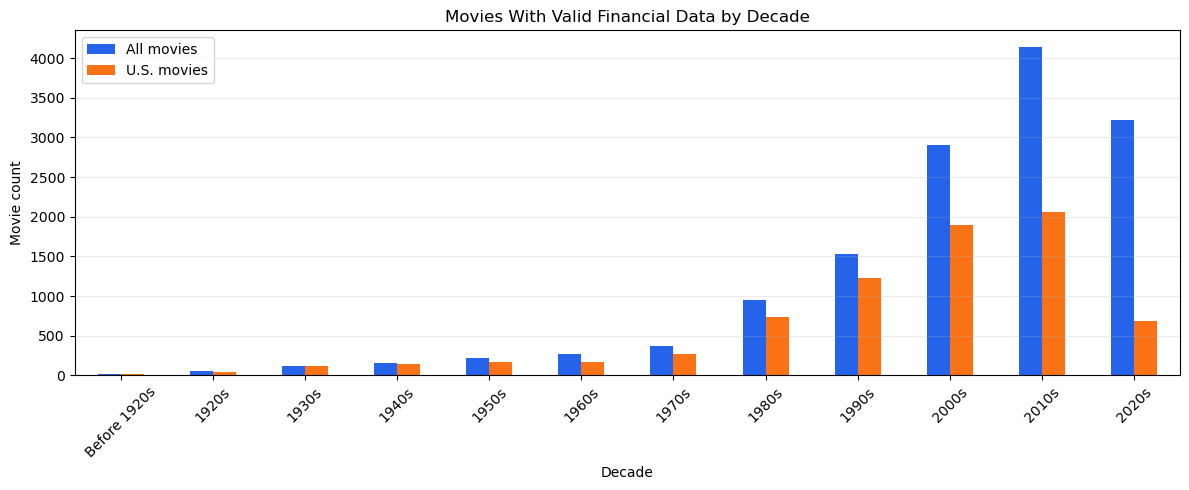

In [13]:
def summary_series(summary, value_column):
    temp = summary.copy()
    temp["period"] = temp["decade"].map(display_decade_label)
    temp["sort"] = temp["decade"].map(decade_sort_value)
    temp = temp.sort_values("sort")
    return temp.set_index("period")[value_column]


def plot_summary_comparison(all_df, us_df, value_column, title, ylabel):
    comparison = pd.DataFrame(
        {
            "All movies": summary_series(all_df, value_column),
            "U.S. movies": summary_series(us_df, value_column),
        }
    )

    ax = comparison.plot(kind="bar", figsize=(12, 5), color=["#2563eb", "#f97316"])
    ax.set_title(title)
    ax.set_xlabel("Decade")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_summary_comparison(
    all_summary,
    us_summary,
    "total_movies",
    "Movies With Valid Financial Data by Decade",
    "Movie count",
)

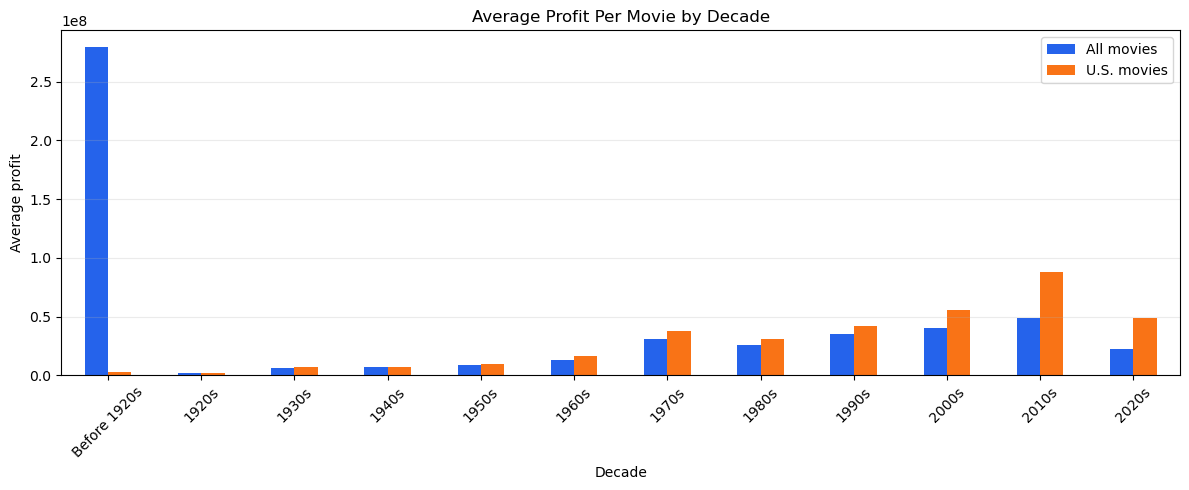

In [14]:
plot_summary_comparison(
    all_summary,
    us_summary,
    "average_profit_per_movie",
    "Average Profit Per Movie by Decade",
    "Average profit",
)

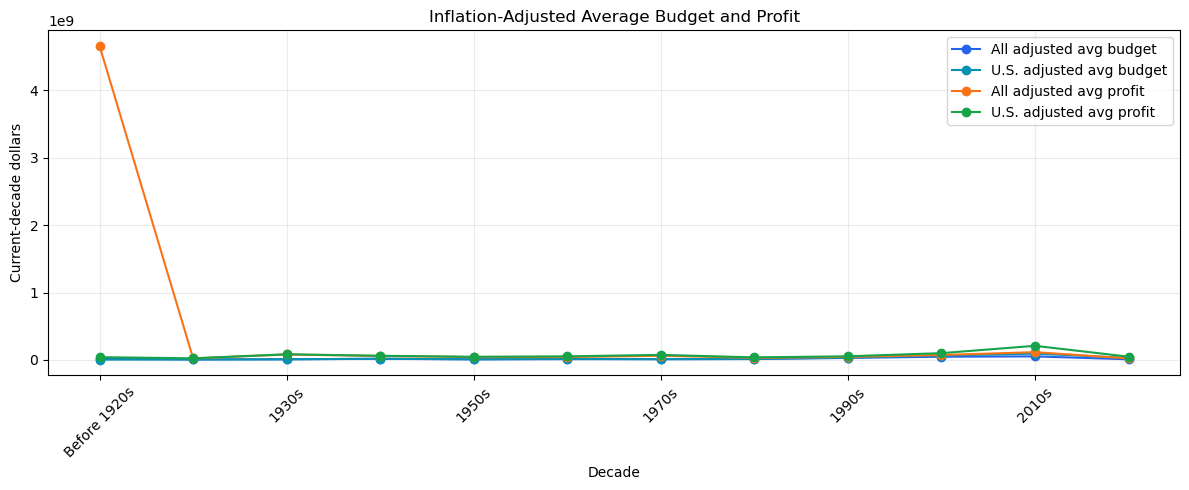

In [15]:
adjusted_comparison = pd.DataFrame(
    {
        "All adjusted avg budget": summary_series(all_inflation_adjusted, "adjusted_budget"),
        "U.S. adjusted avg budget": summary_series(us_inflation_adjusted, "adjusted_budget"),
        "All adjusted avg profit": summary_series(all_inflation_adjusted, "adjusted_average_profit"),
        "U.S. adjusted avg profit": summary_series(us_inflation_adjusted, "adjusted_average_profit"),
    }
)

ax = adjusted_comparison.plot(figsize=(12, 5), marker="o", color=["#2563eb", "#0891b2", "#f97316", "#16a34a"])
ax.set_title("Inflation-Adjusted Average Budget and Profit")
ax.set_xlabel("Decade")
ax.set_ylabel("Current-decade dollars")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

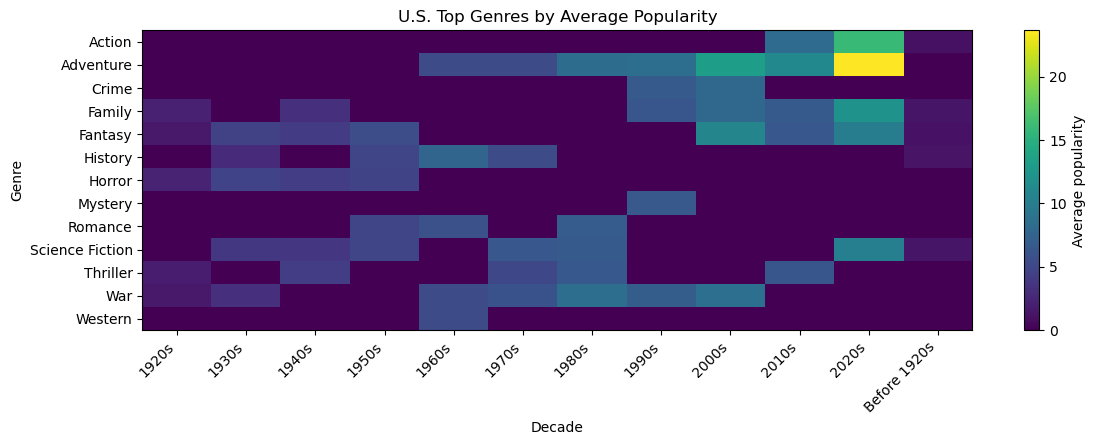

In [16]:
def plot_genre_heatmap(df, value_column, title, colorbar_label):
    if df.empty:
        print("No genre data available for this chart.")
        return

    plot_df = df.copy()
    plot_df["period"] = plot_df["decade"].map(display_decade_label)
    pivot = plot_df.pivot_table(
        index="genre",
        columns="period",
        values=value_column,
        aggfunc="mean",
    )

    ordered_columns = sorted(pivot.columns, key=decade_sort_value)
    pivot = pivot.reindex(columns=ordered_columns)
    data = pivot.fillna(0)

    fig_height = max(4, 0.35 * len(data.index))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    image = ax.imshow(data, aspect="auto", cmap="viridis")

    ax.set_title(title)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Genre")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)
    plt.tight_layout()
    plt.show()


plot_genre_heatmap(
    us_top_genres_by_popularity,
    "average_popularity",
    "U.S. Top Genres by Average Popularity",
    "Average popularity",
)

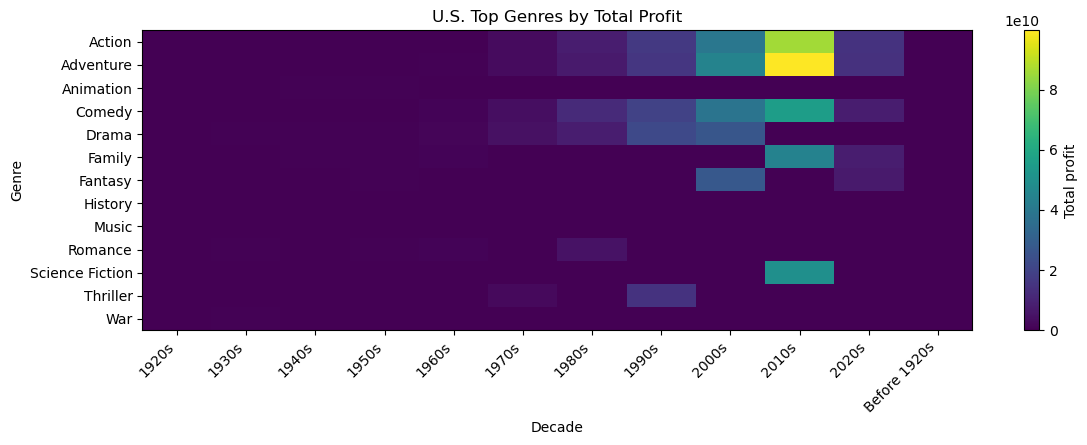

In [17]:
plot_genre_heatmap(
    us_top_genres_by_profit,
    "total_profit",
    "U.S. Top Genres by Total Profit",
    "Total profit",
)

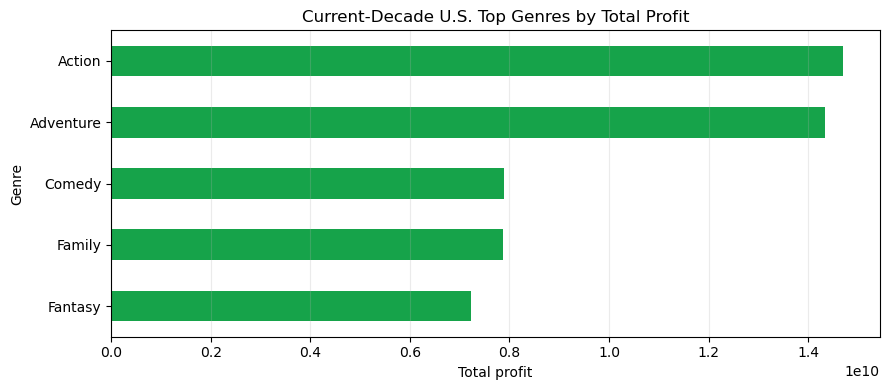

In [18]:
latest_us_profit = us_top_genres_by_profit[
    us_top_genres_by_profit["decade"].map(normalize_decade_label) == "current_decade"
].sort_values("rank")

if latest_us_profit.empty:
    print("No current-decade U.S. profit data available.")
else:
    ax = latest_us_profit.plot(
        kind="barh",
        x="genre",
        y="total_profit",
        figsize=(9, 4),
        color="#16a34a",
        legend=False,
    )
    ax.invert_yaxis()
    ax.set_title("Current-Decade U.S. Top Genres by Total Profit")
    ax.set_xlabel("Total profit")
    ax.set_ylabel("Genre")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()